In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
import pandas as pd

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Load EfficientNetB0 with pretrained ImageNet weights, excluding the top classification layer
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model weights
base_model.trainable = False

# Build the new model
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(23, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.summary()

2026-04-28 10:22:21.669859: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-04-28 10:22:21.669993: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-28 10:22:21.670002: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1777364541.670084 29837092 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1777364541.670163 29837092 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        29,463 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,079,034 (15.56 MB)

 Trainable params: 29,463 (115.09 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [6]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        'chkpts/checkpoint.model.keras',
        monitor="val_loss",
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode="min",
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
]

In [3]:
logos = pd.read_csv("../data/sector_small.csv")
logos.head()
label_to_idx = {label: i for i, label in enumerate(sorted(logos['sector'].unique()))}
image_paths = ('../data/academic/' + logos['domain'] + '.png').values
labels = logos['sector'].map(label_to_idx).values

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32)
    return img, label

In [7]:
n = len(image_paths)
val_size = int(n * 0.2)

dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
dataset = dataset.shuffle(buffer_size=n, seed=42)

val_dataset = dataset.take(val_size).map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)
train_dataset = dataset.skip(val_size).map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.SparseTopKCategoricalAccuracy(
    k=3, name='sparse_top_k_categorical_accuracy', dtype=None
)]
)
model.fit(train_dataset, validation_data=val_dataset, epochs=10, callbacks=callbacks)

Epoch 1/10


2026-04-28 10:36:41.323657: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.0751 - loss: 3.1229 - sparse_top_k_categorical_accuracy: 0.1929
Epoch 1: val_loss improved from None to 2.92659, saving model to chkpts/checkpoint.model.keras

Epoch 1: finished saving model to chkpts/checkpoint.model.keras
550/550 ━━━━━━━━━━━━━━━━━━━━ 116s 197ms/step - accuracy: 0.0860 - loss: 3.0759 - sparse_top_k_categorical_accuracy: 0.2166 - val_accuracy: 0.1264 - val_loss: 2.9266 - val_sparse_top_k_categorical_accuracy: 0.2968
Epoch 2/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.1130 - loss: 2.9702 - sparse_top_k_categorical_accuracy: 0.2741
Epoch 2: val_loss improved from 2.92659 to 2.86191, saving model to chkpts/checkpoint.model.keras

Epoch 2: finished saving model to chkpts/checkpoint.model.keras
550/550 ━━━━━━━━━━━━━━━━━━━━ 104s 190ms/step - accuracy: 0.1121 - loss: 2.9762 - sparse_top_k_categorical_accuracy: 0.2682 - val_accuracy: 0.1443 - val_loss: 2.8619 - val_sparse_top_k_categorical_accuracy: 0.323

2026-04-28 11:06:30.350159: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


138/138 ━━━━━━━━━━━━━━━━━━━━ 22s 159ms/step


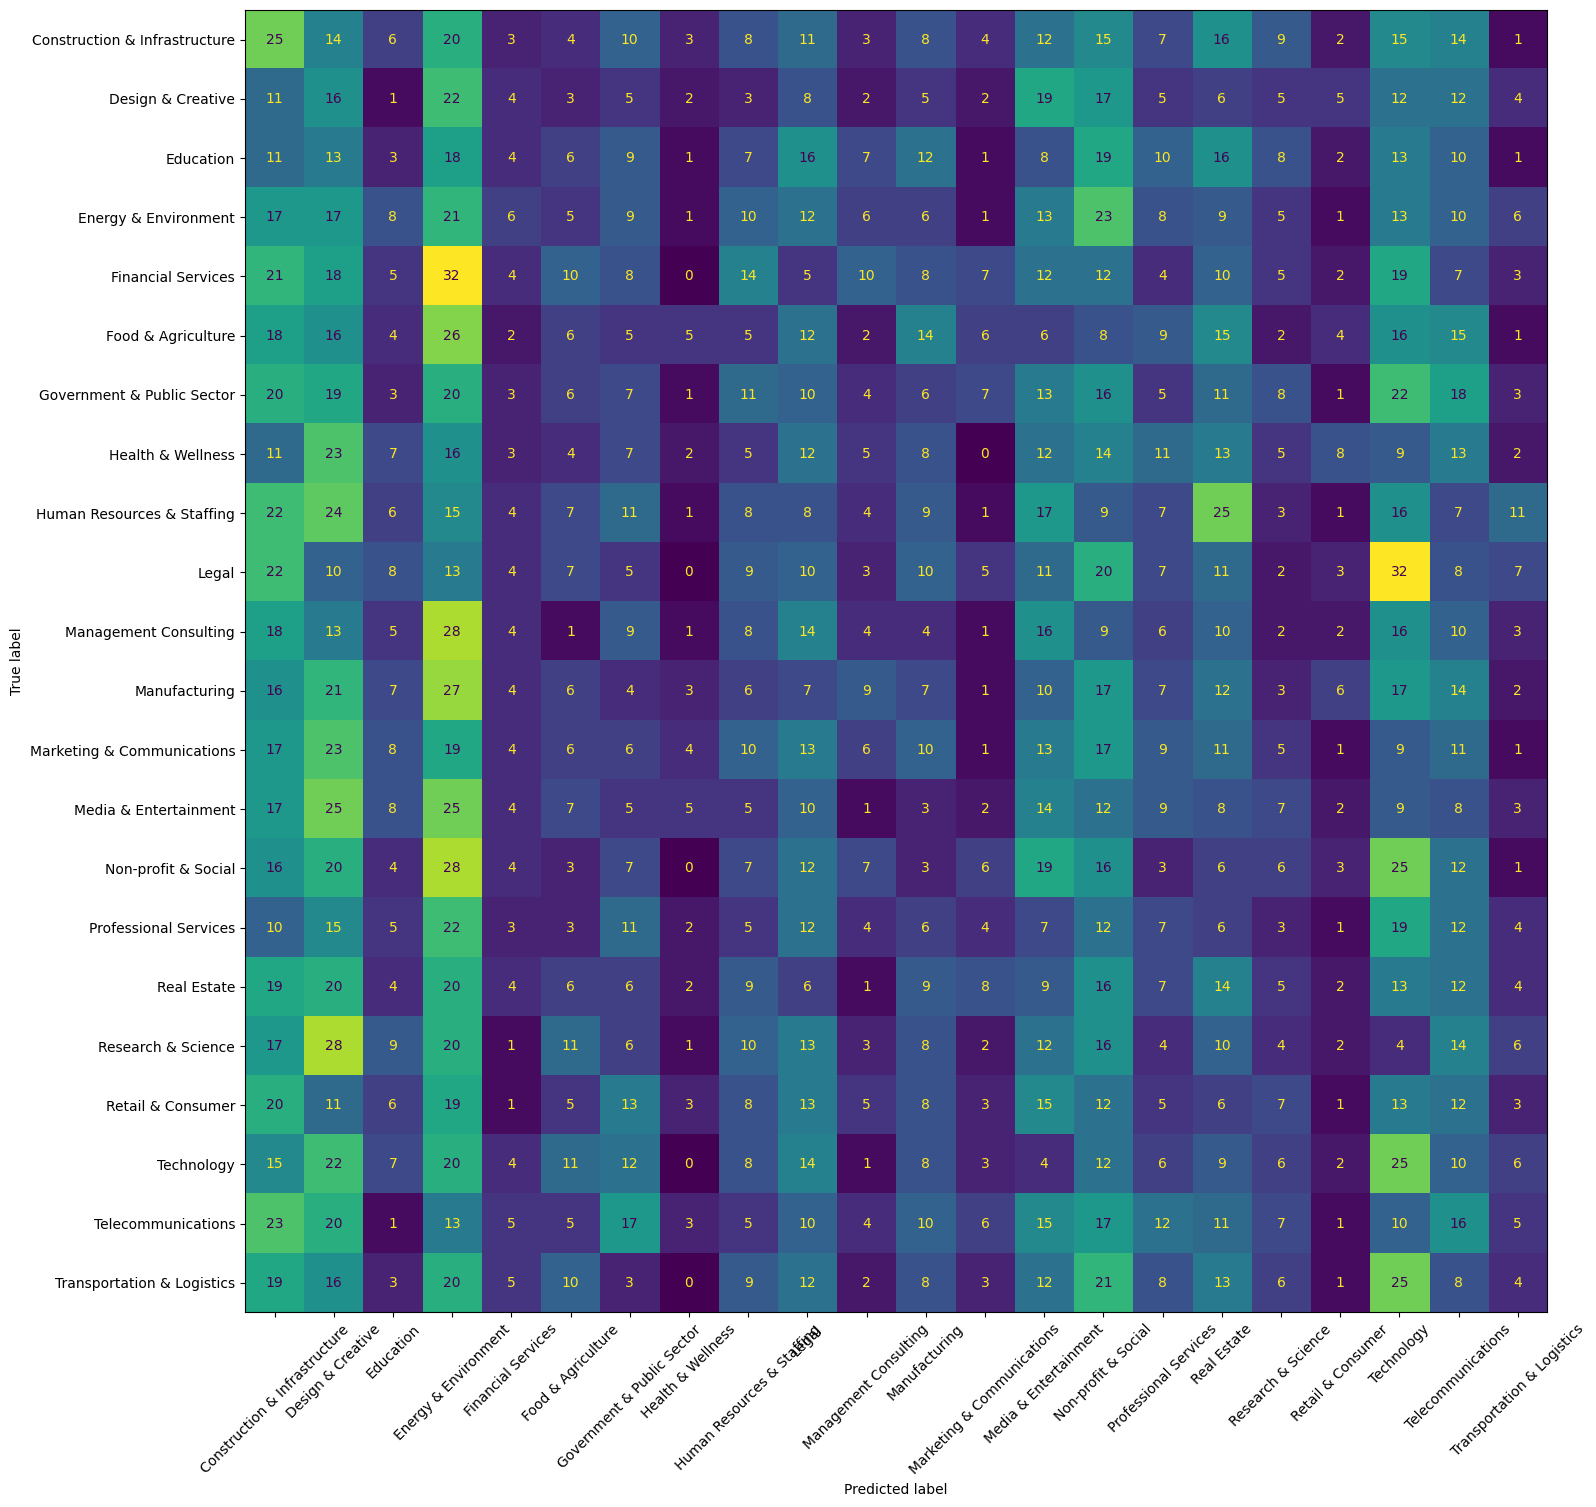

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions AND true labels from val_dataset
true_labels = np.concatenate([y.numpy() for _, y in val_dataset])
preds = model.predict(val_dataset).argmax(axis=1)

# Create and plot
cm = confusion_matrix(true_labels, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=list(label_to_idx.keys()))
fig, ax = plt.subplots(figsize=(16, 16))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.tight_layout()
plt.show()

In [14]:
probs = model.predict(val_dataset)
true_labels = np.concatenate([y.numpy() for _, y in val_dataset])
top3_preds = np.argsort(probs, axis=1)[:, -3:]

idx_to_label = {v: k for k, v in label_to_idx.items()}
for cls_idx in range(len(label_to_idx)):
    mask = true_labels == cls_idx
    if mask.sum() == 0:
        continue
    top3_hits = np.array([true_labels[i] in top3_preds[i] for i in np.where(mask)[0]])
    print(f"{idx_to_label[cls_idx]}: {top3_hits.mean():.2%} top-3 accuracy ({mask.sum()} samples)")

138/138 ━━━━━━━━━━━━━━━━━━━━ 22s 157ms/step
Construction & Infrastructure: 22.96% top-3 accuracy (196 samples)
Design & Creative: 17.67% top-3 accuracy (215 samples)
Education: 9.05% top-3 accuracy (221 samples)
Energy & Environment: 22.83% top-3 accuracy (219 samples)
Financial Services: 8.16% top-3 accuracy (196 samples)
Food & Agriculture: 10.15% top-3 accuracy (197 samples)
Government & Public Sector: 12.63% top-3 accuracy (190 samples)
Health & Wellness: 5.98% top-3 accuracy (184 samples)
Human Resources & Staffing: 11.47% top-3 accuracy (218 samples)
Legal: 17.48% top-3 accuracy (206 samples)
Management Consulting: 16.10% top-3 accuracy (205 samples)
Manufacturing: 15.54% top-3 accuracy (193 samples)
Marketing & Communications: 9.64% top-3 accuracy (197 samples)
Media & Entertainment: 16.99% top-3 accuracy (206 samples)
Non-profit & Social: 20.92% top-3 accuracy (196 samples)
Professional Services: 11.05% top-3 accuracy (172 samples)
Real Estate: 15.53% top-3 accuracy (206 sample